# Import Required Library

In [ ]:
!pip install split-folders

In [ ]:
import os
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import splitfolders
import seaborn as sns
import pandas as pd
import numpy as np


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Gathering

## Download Dataset from Github

In [ ]:
!wget https://github.com/garythung/trashnet/archive/refs/heads/master.zip
!unzip master.zip

--2025-05-23 10:45:38--  https://github.com/garythung/trashnet/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/garythung/trashnet/zip/refs/heads/master [following]
--2025-05-23 10:45:38--  https://codeload.github.com/garythung/trashnet/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.114.9
Connecting to codeload.github.com (codeload.github.com)|140.82.114.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [            <=>     ]  40.63M  11.2MB/s    in 3.6s    

2025-05-23 10:45:42 (11.2 MB/s) - ‘master.zip’ saved [42609527]

Archive:  master.zip
6fa2b878c6c1b4304b91109070ce0edf9279bb31
   creating: trashnet-master/
  inflating: trashnet-master/.gitignore  
  infl

In [ ]:
!unzip '/content/trashnet-master/data/dataset-resized.zip'

Archive:  /content/trashnet-master/data/dataset-resized.zip
   creating: dataset-resized/
  inflating: dataset-resized/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/dataset-resized/
  inflating: __MACOSX/dataset-resized/._.DS_Store  
   creating: dataset-resized/cardboard/
  inflating: dataset-resized/cardboard/cardboard1.jpg  
  inflating: dataset-resized/cardboard/cardboard10.jpg  
  inflating: dataset-resized/cardboard/cardboard100.jpg  
  inflating: dataset-resized/cardboard/cardboard101.jpg  
  inflating: dataset-resized/cardboard/cardboard102.jpg  
  inflating: dataset-resized/cardboard/cardboard103.jpg  
  inflating: dataset-resized/cardboard/cardboard104.jpg  
  inflating: dataset-resized/cardboard/cardboard105.jpg  
  inflating: dataset-resized/cardboard/cardboard106.jpg  
  inflating: dataset-resized/cardboard/cardboard107.jpg  
  inflating: dataset-resized/cardboard/cardboard108.jpg  
  inflating: dataset-resized/cardboard/cardboard109.jpg  
  inflating: dataset-r

## Define Directory

In [ ]:
BASE_DIR = '/content/dataset-resized'

## Explore Dataset

In [ ]:
class_names = [folder for folder in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, folder))]
print("Jumlah kelas:", len(class_names))
print("Nama kelas:", class_names)

Jumlah kelas: 6
Nama kelas: ['paper', 'plastic', 'cardboard', 'glass', 'metal', 'trash']


In [ ]:
# Untuk menyimpan semua ukuran gambar
sizes = []

for class_name in class_names:
    class_folder = os.path.join(BASE_DIR, class_name)
    for fname in os.listdir(class_folder):
        file_path = os.path.join(class_folder, fname)
        try:
            with Image.open(file_path) as img:
                sizes.append(img.size)  # (width, height)
        except Exception as e:
            print(f"Gagal membaca {file_path}: {e}")

# Hitung jumlah kombinasi ukuran unik
size_counts = Counter(sizes)
print("Ukuran unik dan jumlahnya:", size_counts)
print("Total gambar:", len(sizes))

# Cek apakah semua gambar square (panjang = lebar)
square_count = sum([1 for s in sizes if s[0] == s[1]])
print(f"Jumlah gambar square (panjang=lebar): {square_count} dari {len(sizes)} gambar")

if len(size_counts) == 1:
    print("Semua gambar memiliki ukuran yang seragam:", list(size_counts.keys())[0])
else:
    print("Terdapat lebih dari satu ukuran gambar!")

Ukuran unik dan jumlahnya: Counter({(512, 384): 2527})
Total gambar: 2527
Jumlah gambar square (panjang=lebar): 0 dari 2527 gambar
Semua gambar memiliki ukuran yang seragam: (512, 384)


In [ ]:
jumlah_per_kelas = {}

for class_name in class_names:
    class_folder = os.path.join(BASE_DIR, class_name)
    # Hanya hitung file, bukan folder, di dalam folder kelas
    gambar = [f for f in os.listdir(class_folder) if os.path.isfile(os.path.join(class_folder, f))]
    jumlah_per_kelas[class_name] = len(gambar)

# Tampilkan jumlah gambar per kelas
for kelas, jumlah in jumlah_per_kelas.items():
    print(f"Kelas '{kelas}': {jumlah} gambar")

# Total gambar di seluruh dataset
total = sum(jumlah_per_kelas.values())
print(f"\nTotal gambar di seluruh kelas: {total}")

Kelas 'paper': 594 gambar
Kelas 'plastic': 482 gambar
Kelas 'cardboard': 403 gambar
Kelas 'glass': 501 gambar
Kelas 'metal': 410 gambar
Kelas 'trash': 137 gambar

Total gambar di seluruh kelas: 2527


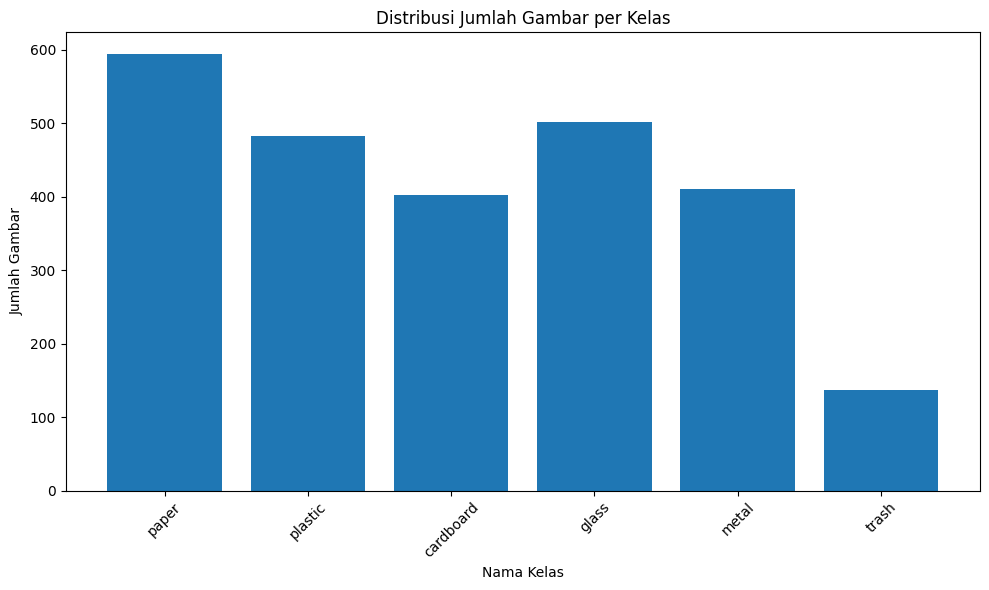

In [ ]:
# Bar plot jumlah gambar per kelas
plt.figure(figsize=(10, 6))
plt.bar(jumlah_per_kelas.keys(), jumlah_per_kelas.values())
plt.xlabel('Nama Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Load Metadata Gambar

In [ ]:
def get_image_metadata(dataset_path):
    data = []
    for label in os.listdir(dataset_path):
        label_path = os.path.join(dataset_path, label)
        if not os.path.isdir(label_path):
            continue
        for fname in os.listdir(label_path):
            fpath = os.path.join(label_path, fname)
            try:
                with Image.open(fpath) as img:
                    width, height = img.size
                    mode = img.mode
                data.append({
                    'filepath': fpath,
                    'label': label,
                    'width': width,
                    'height': height,
                    'mode': mode
                })
            except:
                print(f"Corrupted image: {fpath}")
    return pd.DataFrame(data)

dataset_path = BASE_DIR
df = get_image_metadata(dataset_path)
df.head()

,filepath,label,width,height,mode
0,/content/dataset-resized/paper/paper167.jpg,paper,512,384,RGB
1,/content/dataset-resized/paper/paper166.jpg,paper,512,384,RGB
2,/content/dataset-resized/paper/paper227.jpg,paper,512,384,RGB
3,/content/dataset-resized/paper/paper73.jpg,paper,512,384,RGB
4,/content/dataset-resized/paper/paper155.jpg,paper,512,384,RGB


In [ ]:
df.tail()

,filepath,label,width,height,mode
2522,/content/dataset-resized/trash/trash51.jpg,trash,512,384,RGB
2523,/content/dataset-resized/trash/trash83.jpg,trash,512,384,RGB
2524,/content/dataset-resized/trash/trash3.jpg,trash,512,384,RGB
2525,/content/dataset-resized/trash/trash109.jpg,trash,512,384,RGB
2526,/content/dataset-resized/trash/trash48.jpg,trash,512,384,RGB


# Distribusi Ukuran Gambar

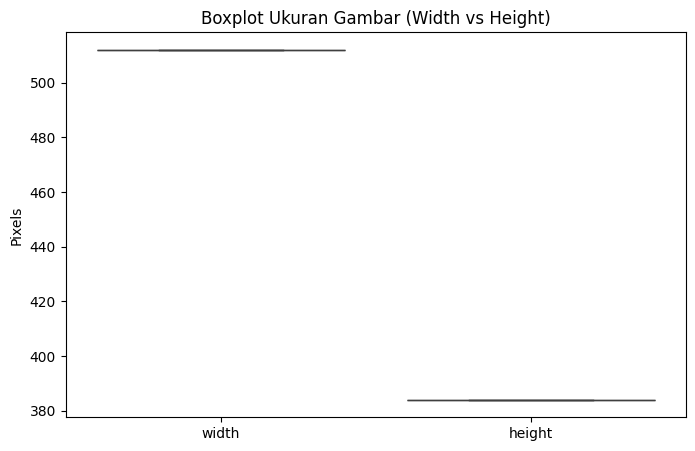

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['width', 'height']])
plt.title("Boxplot Ukuran Gambar (Width vs Height)")
plt.ylabel("Pixels")
plt.show()


# Contoh Gambar per Kelas

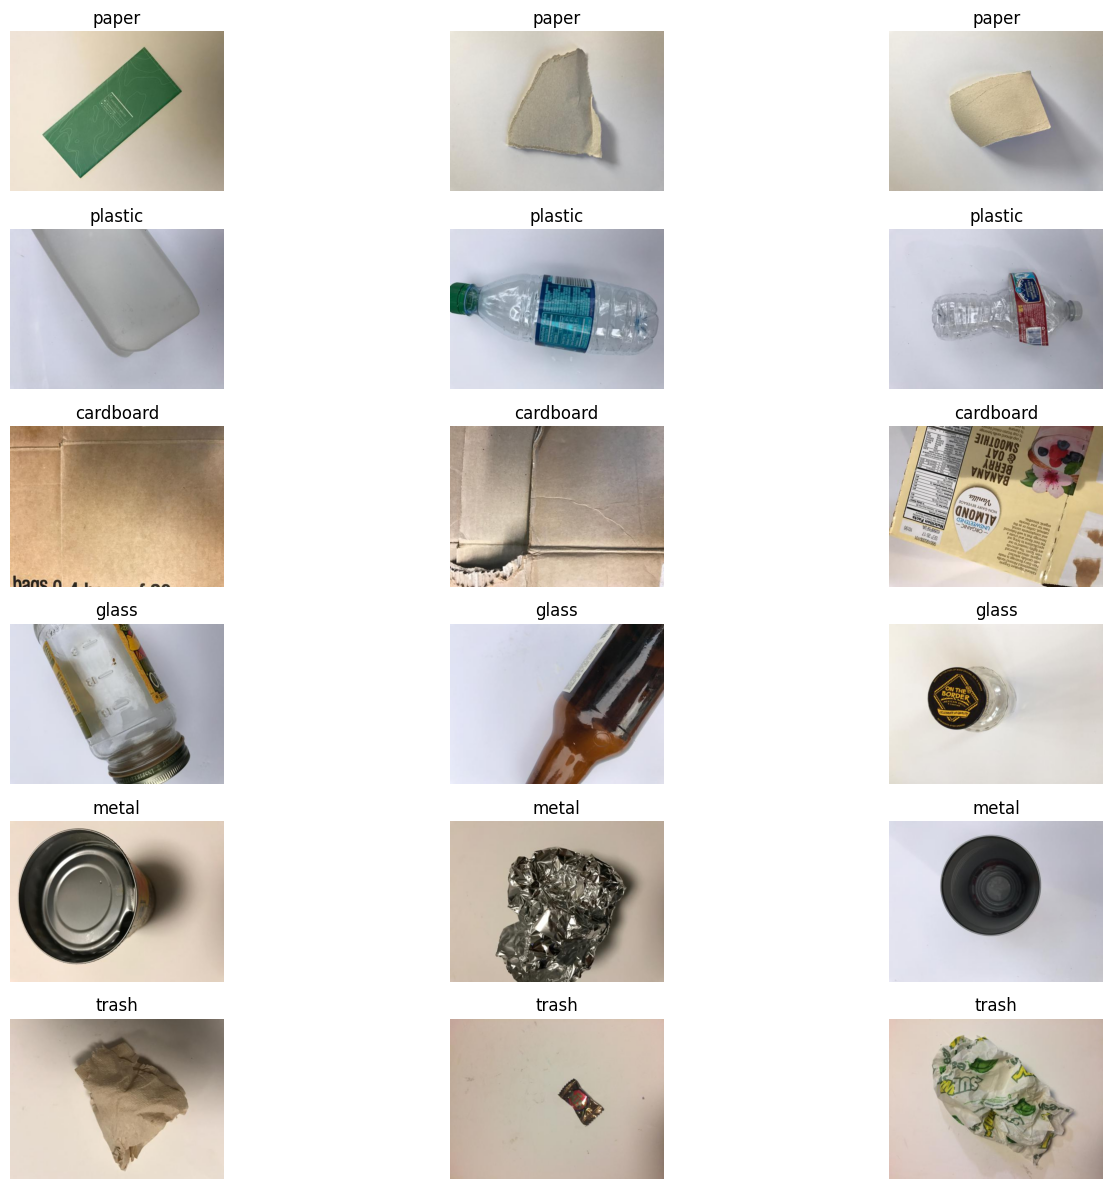

In [ ]:
def show_samples(df, num_per_class=3):
    labels = df['label'].unique()
    plt.figure(figsize=(15, len(labels) * 2))
    for i, label in enumerate(labels):
        subset = df[df['label'] == label].sample(num_per_class)
        for j, row in enumerate(subset.itertuples()):
            plt.subplot(len(labels), num_per_class, i * num_per_class + j + 1)
            img = Image.open(row.filepath)
            plt.imshow(img)
            plt.title(label)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(df)

#  Cek Mode (RGB vs Grayscale)

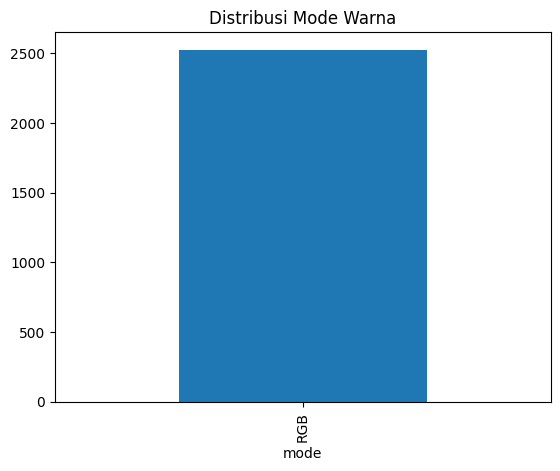

In [ ]:
df['mode'].value_counts().plot(kind='bar', title="Distribusi Mode Warna")
plt.show()

In [ ]:
bad_files = []
for f in df['filepath']:
    try:
        Image.open(f).verify()
    except:
        bad_files.append(f)
print(f"Jumlah file korup: {len(bad_files)}")

Jumlah file korup: 0


# Data Splitting

In [ ]:
# make output directory
OUTPUT_DIR = 'dataset-split'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
!pip install split-folders

In [ ]:
splitfolders.ratio(BASE_DIR, output=OUTPUT_DIR, seed=42, ratio=(0.7, 0.15, 0.15))

Copying files: 2527 files [00:00, 8886.01 files/s]


In [ ]:
splits = ['train', 'val', 'test']

for split in splits:
    split_path = os.path.join(OUTPUT_DIR, split)
    classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
    print(f"\nSplit: {split}")
    for class_name in classes:
        class_dir = os.path.join(split_path, class_name)
        num_images = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
        print(f"  Kelas '{class_name}': {num_images} gambar")


Split: train
  Kelas 'paper': 415 gambar
  Kelas 'plastic': 337 gambar
  Kelas 'cardboard': 282 gambar
  Kelas 'glass': 350 gambar
  Kelas 'metal': 287 gambar
  Kelas 'trash': 95 gambar

Split: val
  Kelas 'paper': 89 gambar
  Kelas 'plastic': 72 gambar
  Kelas 'cardboard': 60 gambar
  Kelas 'glass': 75 gambar
  Kelas 'metal': 61 gambar
  Kelas 'trash': 20 gambar

Split: test
  Kelas 'paper': 90 gambar
  Kelas 'plastic': 73 gambar
  Kelas 'cardboard': 61 gambar
  Kelas 'glass': 76 gambar
  Kelas 'metal': 62 gambar
  Kelas 'trash': 22 gambar


# Image Augmentation

In [ ]:
train_dir = os.path.join(OUTPUT_DIR, 'train')
val_dir = os.path.join(OUTPUT_DIR, 'val')
test_dir = os.path.join(OUTPUT_DIR, 'test')

# Augmentasi hanya untuk data train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & test hanya rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),   # Ubah sesuai kebutuhan
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1766 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Found 384 images belonging to 6 classes.


# Inisiasi Callbacks

In [ ]:
# Inisiasi Callback
class MyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.95 and logs.get('val_accuracy') >0.95):
            print("\nReached 95% validation accuracy, Stop training!")
            self.model.stop_training = True

CALLBACK = MyCallback()

# Model Development

In [ ]:
# Load base model MobileNet tanpa top layer (include_top=False)
base_model = tf.keras.applications.MobileNet(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False # Bekukan layer

# Buat model dengan MobileNet + custom classifier di atasnya
model = tf.keras.models.Sequential([
    base_model,

    # # feature extraction layer
    # tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    # tf.keras.layers.MaxPooling2D(2, 2),

    # reshape feature map
    tf.keras.layers.GlobalAveragePooling2D(),

    # dropout regularization
    tf.keras.layers.Dropout(0.2),

    # fully connected layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['accuracy'])
model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional)      │ (None, 7, 7, 1024)          │       3,228,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,294,854 (12.57 MB)

 Trainable params: 3,272,966 (12.49 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Hitung class weights
class_labels = [label for label in train_generator.classes]
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: 1.0437352245862883, 1: 0.840952380952381, 2: 1.0255516840882695, 3: 0.7092369477911646, 4: 0.8733926805143423, 5: 3.0982456140350876}


In [ ]:
# Fitting / training model
history_1 = model.fit(train_generator,
                      epochs=30,
                      batch_size=32,
                      validation_data=val_generator,
                      callbacks=[CALLBACK],
                      class_weight=class_weights)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
42/56 ━━━━━━━━━━━━━━━━━━━━ 9s 705ms/step - accuracy: 0.5236 - loss: 1.3402 

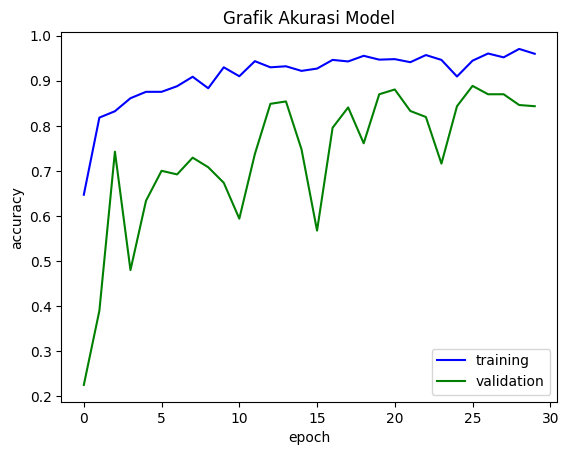

<Figure size 640x480 with 0 Axes>

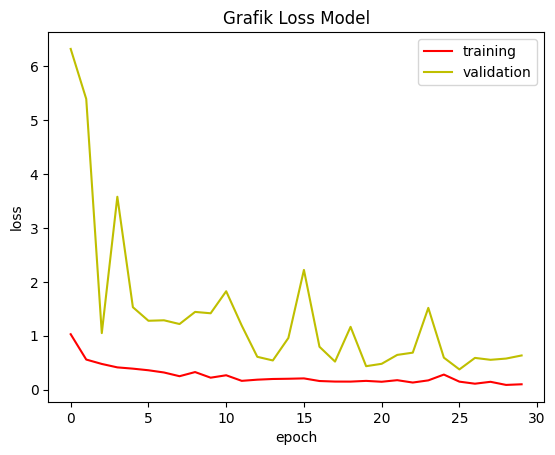

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = history_1.history['accuracy']               #Nilai akurasi training
val_acc = history_1.history['val_accuracy']       #Nilai akurasi validation

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='training')
plt.plot(epochs, val_acc, 'g', label='validation')
plt.title('Grafik Akurasi Model')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

loss = history_1.history['loss']                  #Nilai loss training
val_loss = history_1.history['val_loss']          #Nilai loss validation

plt.plot(epochs, loss, 'r', label='training')
plt.plot(epochs, val_loss, 'y', label='validation')
plt.title('Grafik Loss Model')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc=0)
plt.figure()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


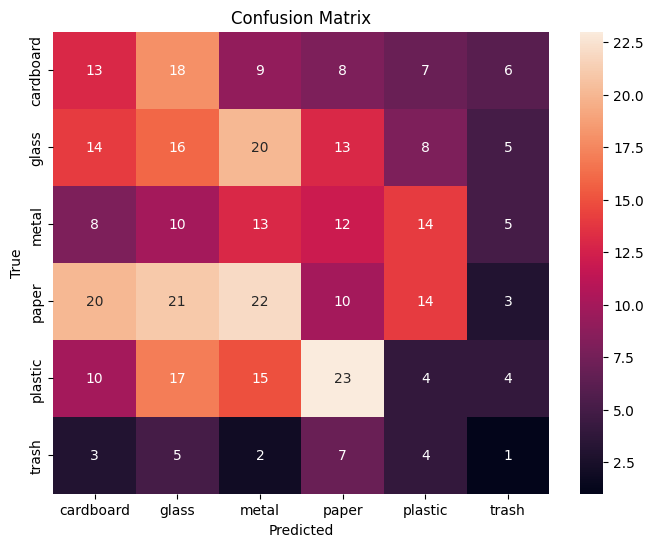

In [ ]:
from sklearn.metrics import confusion_matrix

# Prediksi semua data di test set
pred_probs = model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)  # ambil index kelas dengan prob tertinggi

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Classification report
report = classification_report(true_classes, pred_classes, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

   cardboard       0.19      0.21      0.20        61
       glass       0.18      0.21      0.20        76
       metal       0.16      0.21      0.18        62
       paper       0.14      0.11      0.12        90
     plastic       0.08      0.05      0.06        73
       trash       0.04      0.05      0.04        22

    accuracy                           0.15       384
   macro avg       0.13      0.14      0.14       384
weighted avg       0.14      0.15      0.14       384



# Eksperimen

In [ ]:
def plot_image(predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(
        class_names[predicted_label],
        100 * np.max(predictions_array),
        class_names[true_label]
    ), color=color)

def plot_value_array(predictions_array, true_label):
    plt.grid(False)
    plt.xticks(range(len(class_names)))
    plt.yticks([])
    thisplot = plt.bar(range(len(class_names)), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

In [ ]:
img_height = 224
img_width = 224

# Ambil nama label (kelas)
class_names = sorted(os.listdir(test_dir))

selected_images = []
selected_labels = []

# Untuk setiap kelas, ambil satu gambar
for idx, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    image_names = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    img_path = os.path.join(class_path, image_names[0])

    # Load gambar
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(img_height, img_width))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0

    selected_images.append(img_array)
    selected_labels.append(idx)

selected_images = np.array(selected_images)
selected_labels = np.array(selected_labels)

In [ ]:
# Model probabilitas
probability_model = tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax()
])

predictions = probability_model.predict(selected_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


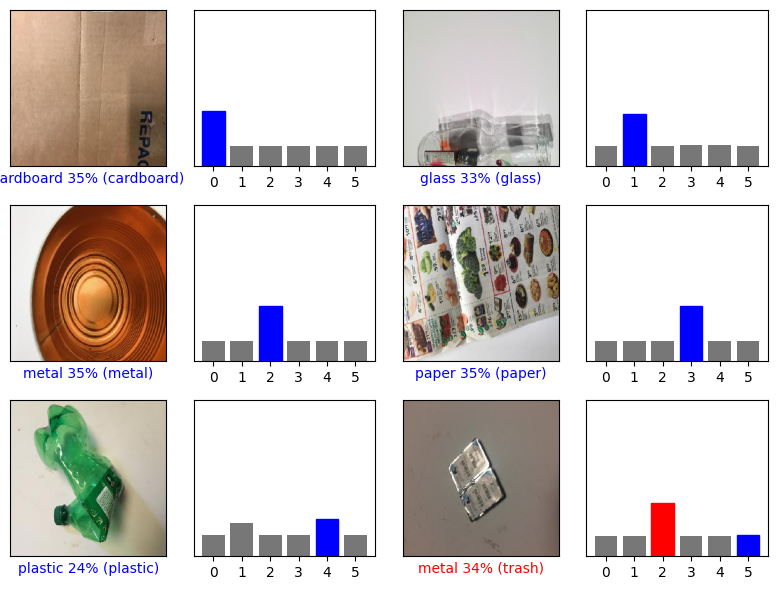

In [ ]:
num_rows = 3
num_cols = 2
num_images = num_rows * num_cols

plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(predictions[i], selected_labels[i], selected_images[i])

    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(predictions[i], selected_labels[i])

plt.tight_layout()
plt.show()

In [ ]:
import os

# Tentukan path direktori yang ingin dibuat
model_directory = 'model'

# Periksa apakah direktori sudah ada
if not os.path.exists(model_directory):
    try:
        # Membuat direktori
        os.makedirs(model_directory)
        print(f"Direktori '{model_directory}' berhasil dibuat.")
    except OSError as e:
        print(f"Gagal membuat direktori '{model_directory}': {e}")
else:
    print(f"Direktori '{model_directory}' sudah ada.")

Direktori 'model' sudah ada.


In [ ]:
# konversi model ke format joblib
import joblib
filename = 'model/model.joblib'
joblib.dump(model, filename)
print(f"Model berhasil disimpan ke {filename}")

Model berhasil disimpan ke model/model.joblib


# Imbalance Handling

In [ ]:
import os
from collections import Counter

class_counts = Counter()
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))
print(class_counts)


Counter({'paper': 415, 'glass': 350, 'plastic': 337, 'metal': 287, 'cardboard': 282, 'trash': 95})


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img, save_img
import numpy as np
import os

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

target_count = max(class_counts.values())

for class_name in class_counts:
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('jpg','jpeg','png'))]
    n_to_generate = target_count - len(images)
    i = 0
    while n_to_generate > 0:
        img_name = images[i % len(images)]
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path, target_size=(224,224))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)
        aug_iter = datagen.flow(x, batch_size=1)
        aug_img = next(aug_iter)[0].astype('uint8')
        aug_img_path = os.path.join(class_path, f'aug_{i}_{img_name}')
        save_img(aug_img_path, aug_img)
        n_to_generate -= 1
        i += 1


In [ ]:
# Hitung jumlah gambar per kelas SESUDAH augmentasi
after_counts = Counter()
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('jpg','jpeg','png'))])
        after_counts[class_name] = num_images

print("\nJumlah gambar sesudah augmentasi:")
for class_name, count in after_counts.items():
    print(f"{class_name}: {count}")



Jumlah gambar sesudah augmentasi:
paper: 415
plastic: 415
cardboard: 415
glass: 415
metal: 415
trash: 415


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Untuk train (augmentasi sudah dilakukan, cukup rescale)
train_datagen = ImageDataGenerator(rescale=1./255)

# Untuk validasi & test
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 2490 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Found 384 images belonging to 6 classes.


In [ ]:
# Fitting / training model
history = model.fit(train_generator,
                      epochs=30,
                      batch_size=32,
                      validation_data=val_generator,
                      callbacks=[CALLBACK])

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 273ms/step - accuracy: 0.9631 - loss: 0.1043 - val_accuracy: 0.8674 - val_loss: 0.4427
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9832 - loss: 0.0504 - val_accuracy: 0.8621 - val_loss: 0.4863
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9831 - loss: 0.0567 - val_accuracy: 0.8594 - val_loss: 0.6184
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.9885 - loss: 0.0285 - val_accuracy: 0.8727 - val_loss: 0.4816
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.9878 - loss: 0.0457 - val_accuracy: 0.9019 - val_loss: 0.3178
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.9940 - loss: 0.0210 - val_accuracy: 0.9045 - val_loss: 0.4224
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.9832 - loss: 0.0456 - val_accuracy: 0.7454 - val_loss: 1.4628
Epoch 8/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.9875 - loss: 0.0393 - val_accuracy: 0.8939 - va

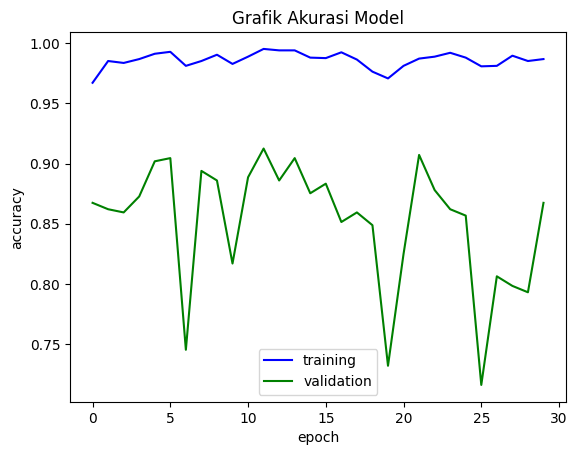

<Figure size 640x480 with 0 Axes>

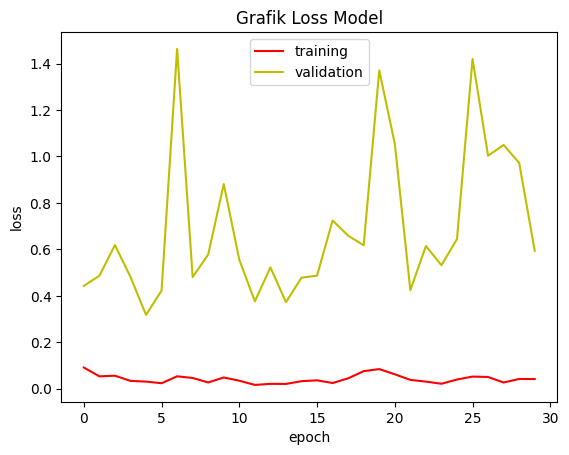

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = history.history['accuracy']               #Nilai akurasi training
val_acc = history.history['val_accuracy']       #Nilai akurasi validation

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='training')
plt.plot(epochs, val_acc, 'g', label='validation')
plt.title('Grafik Akurasi Model')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

loss = history.history['loss']                  #Nilai loss training
val_loss = history.history['val_loss']          #Nilai loss validation

plt.plot(epochs, loss, 'r', label='training')
plt.plot(epochs, val_loss, 'y', label='validation')
plt.title('Grafik Loss Model')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc=0)
plt.figure()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step


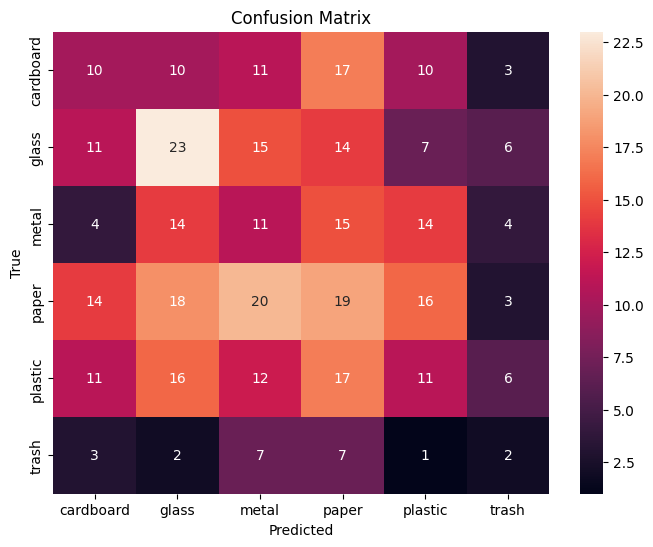

In [ ]:
from sklearn.metrics import confusion_matrix

# Prediksi semua data di test set
pred_probs = model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)  # ambil index kelas dengan prob tertinggi

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Classification report
report = classification_report(true_classes, pred_classes, target_names=class_labels)
print(report)

              precision    recall  f1-score   support

   cardboard       0.19      0.16      0.18        61
       glass       0.28      0.30      0.29        76
       metal       0.14      0.18      0.16        62
       paper       0.21      0.21      0.21        90
     plastic       0.19      0.15      0.17        73
       trash       0.08      0.09      0.09        22

    accuracy                           0.20       384
   macro avg       0.18      0.18      0.18       384
weighted avg       0.20      0.20      0.20       384



Note eksplorasi
1. hyperparameter tuning:
- regularization
- learning rate
- dropout rate
- weight decay
- optimizer (SGD)
2. dataset split
- augmentasi -> train-val-test
- train-test split -> augmentasi train -> split train-val